# Two moon with an invertible neural network 

In [75]:
# Two moon with an invertible neural network

# In this example, we will use an invertible neural network to model the two moon dataset. That is, use a RealNVP to learn the distribution of the two moon dataset.

""" A RealNVP consist of coupling layers,  A RealNVP consists of coupling blocks, where
the second half of the dimensions is transformed by a linear function whose coefcients depend on
the first half. The coefficients are calculated with nested neural networks with two hidden layers
(with ReLU activation) and a linear output layer (for the translation coefficient) resp. a linear
layer followed by exp(tanh(˜s)) (for the scaling coefficient).   """



' A RealNVP consist of coupling layers,  A RealNVP consists of coupling blocks, where\nthe second half of the dimensions is transformed by a linear function whose coefcients depend on\nthe first half. The coefficients are calculated with nested neural networks with two hidden layers\n(with ReLU activation) and a linear output layer (for the translation coefficient) resp. a linear\nlayer followed by exp(tanh(˜s)) (for the scaling coefficient).   '

In [76]:
import torch
import torch.nn as nn
from sklearn.datasets import make_moons
import math
from scipy.stats import special_ortho_group
import random
import matplotlib.pyplot as plt


Text(0.5, 1.0, 'Two moon dataset')

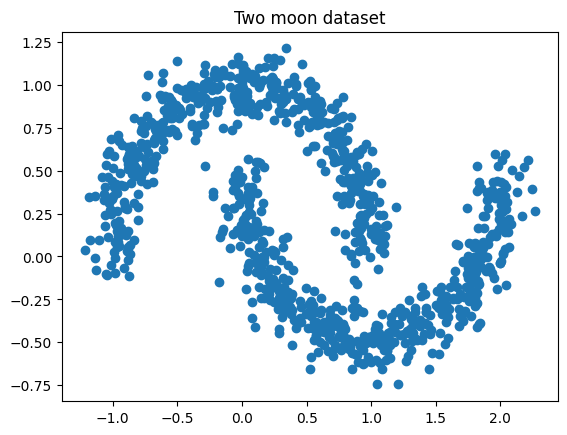

In [77]:
test_x_, _ = make_moons(n_samples=1000, shuffle=True, noise=0.1, random_state=42)
plt.scatter(test_x_[:, 0], test_x_[:, 1], )
plt.title("Two moon dataset")

In [78]:
def subnet_constructor(input_size, hidden_size, output_size):
    model = nn.Sequential(
        nn.Linear(input_size, hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, output_size)
    )
    return model

In [79]:
def orthogoanl_matrix(dim):
    """ A = torch.normal (mean = torch.zeros (dim, dim), std = torch.ones (dim, dim))
    Q, _ = torch.qr (A)
    if dim == 2:
        Q[1,1] = -Q[0,0]
        Q[1,0] = -Q[0,1]
    print (torch.linalg.det(Q))
    return Q
    """
    Q = special_ortho_group.rvs(dim)
    return torch.Tensor (Q)

In [80]:
class coupling_block(nn.Module):
 def __init__(self, input_size, hidden_size):
    super().__init__()
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.split1 = math.floor(self.input_size/2)
    self.split2 = self.input_size - self.split1
    self.subnet = subnet_constructor(self.split1, self.hidden_size, 2*self.split2)
 def forward(self, x, rev=False):
    x1, x2 = x[..., :self.split1], x[..., self.split1:]
    params = self.subnet(x1)
    s, t = params[...,:self.split2], params[...,self.split2:]
    s = torch.tanh(s)
    ljd = torch.sum(s, -1)
    if not rev:
        s = torch.exp(s)
        x2 = s*x2 + t
        return torch.cat([x1,x2], -1), ljd
    if rev:
        s = torch.exp(-s)
        x2 = s * (x2-t)
        return torch.cat([x1,x2], -1)

In [81]:
class realNVP(nn.Module): 
    def __init__(self, input_size, hidden_size, n_blocks):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.n_blocks = n_blocks

        self.coupling_blocks = nn.ModuleList([coupling_block(input_size, hidden_size) for _ in range(n_blocks)])
        self.orthogonal_matrices = [orthogoanl_matrix(input_size) for _ in range(n_blocks-1)]

    def forward(self, x, rev=False):
        if rev: return self._inverse(x)
        return self._forward(x)
    def _forward(self, x):
        ljd = torch.zeros((x.shape[0]))
        for l in range(self.n_blocks-1):
            x, partial_ljd = self.coupling_blocks[l](x)
            ljd += partial_ljd
            x = torch.matmul(x, self.orthogonal_matrices[l])
        x, partial_ljd = self.coupling_blocks[-1](x)
        ljd += partial_ljd
        return x, ljd
    def _inverse(self, x):
        for l in range (self.n_blocks-1, 0, -1):
            x = self.coupling_blocks[l](x, rev=True)
            x = torch.matmul(x, self.orthogonal_matrices[l-1].T)
        x = self.coupling_blocks[0](x, rev=True)
        return x
    def sample(self, num_samples):
        z = torch.normal(mean=torch.zeros((num_samples, self.input_size)), std=torch.ones((num_samples, self.input_size)))
        return self._inverse(z)
    
    

In [87]:
def train_inn(model, batchsize=1000, epochs=1000, lr=0.001):
    optimizer = torch.optim.Adam(params=model.parameters(), lr=lr)
    for epoch in range(epochs):
        optimizer.zero_grad()
        x_data, y_data = make_moons(n_samples=batchsize, shuffle=True, noise=0.1, random_state=42)
        x_data, y_data = torch.Tensor(x_data), torch.Tensor(y_data)
        z, ljd = model(x_data)
        loss = torch.sum(0.5*torch.sum(z**2, -1)-ljd) / batchsize
        loss.backward()
        optimizer.step()
        if (epoch+1) % (epochs//3) == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

In [88]:
def plot_samples(model, title="Generated samples from INN", axs=None):
 samples = model.sample(1000)
 samples = samples.detach().numpy()
 if axs is None:
  fig, axs = plt.subplots(1,1)
  axs.scatter(samples[:,0], samples[:,1])
  axs.set_title(title)
 else:
  axs.scatter(samples[:,0], samples[:,1])
  axs.set_title(title)

Training of INN with hidden_size 16 and 2 coupling blocks started.
Epoch [33/100], Loss: 0.1775
Epoch [66/100], Loss: 0.0847
Epoch [99/100], Loss: 0.0299
Training of INN with hidden_size 64 and 2 coupling blocks started.
Epoch [33/100], Loss: 0.0992
Epoch [66/100], Loss: 0.0154
Epoch [99/100], Loss: -0.0517
Training of INN with hidden_size 128 and 2 coupling blocks started.
Epoch [33/100], Loss: -0.1078
Epoch [66/100], Loss: -0.2244
Epoch [99/100], Loss: -0.2627
Training of INN with hidden_size 16 and 5 coupling blocks started.
Epoch [33/100], Loss: 0.1169
Epoch [66/100], Loss: 0.0118
Epoch [99/100], Loss: -0.0627
Training of INN with hidden_size 64 and 5 coupling blocks started.
Epoch [33/100], Loss: -0.2042
Epoch [66/100], Loss: -0.3756
Epoch [99/100], Loss: -0.4653
Training of INN with hidden_size 128 and 5 coupling blocks started.
Epoch [33/100], Loss: -0.2575
Epoch [66/100], Loss: -0.4095
Epoch [99/100], Loss: -0.4837
Training of INN with hidden_size 16 and 10 coupling blocks star

Training of INN with hidden_size 16 and 2 coupling blocks started.
Epoch [33/100], Loss: 0.1775
Epoch [66/100], Loss: 0.0847
Epoch [99/100], Loss: 0.0299
Training of INN with hidden_size 64 and 2 coupling blocks started.
Epoch [33/100], Loss: 0.0992
Epoch [66/100], Loss: 0.0154
Epoch [99/100], Loss: -0.0517
Training of INN with hidden_size 128 and 2 coupling blocks started.
Epoch [33/100], Loss: -0.1078
Epoch [66/100], Loss: -0.2244
Epoch [99/100], Loss: -0.2627
Training of INN with hidden_size 16 and 5 coupling blocks started.
Epoch [33/100], Loss: 0.1169
Epoch [66/100], Loss: 0.0118
Epoch [99/100], Loss: -0.0627
Training of INN with hidden_size 64 and 5 coupling blocks started.
Epoch [33/100], Loss: -0.2042
Epoch [66/100], Loss: -0.3756
Epoch [99/100], Loss: -0.4653
Training of INN with hidden_size 128 and 5 coupling blocks started.
Epoch [33/100], Loss: -0.2575
Epoch [66/100], Loss: -0.4095
Epoch [99/100], Loss: -0.4837
Training of INN with hidden_size 16 and 10 coupling blocks star

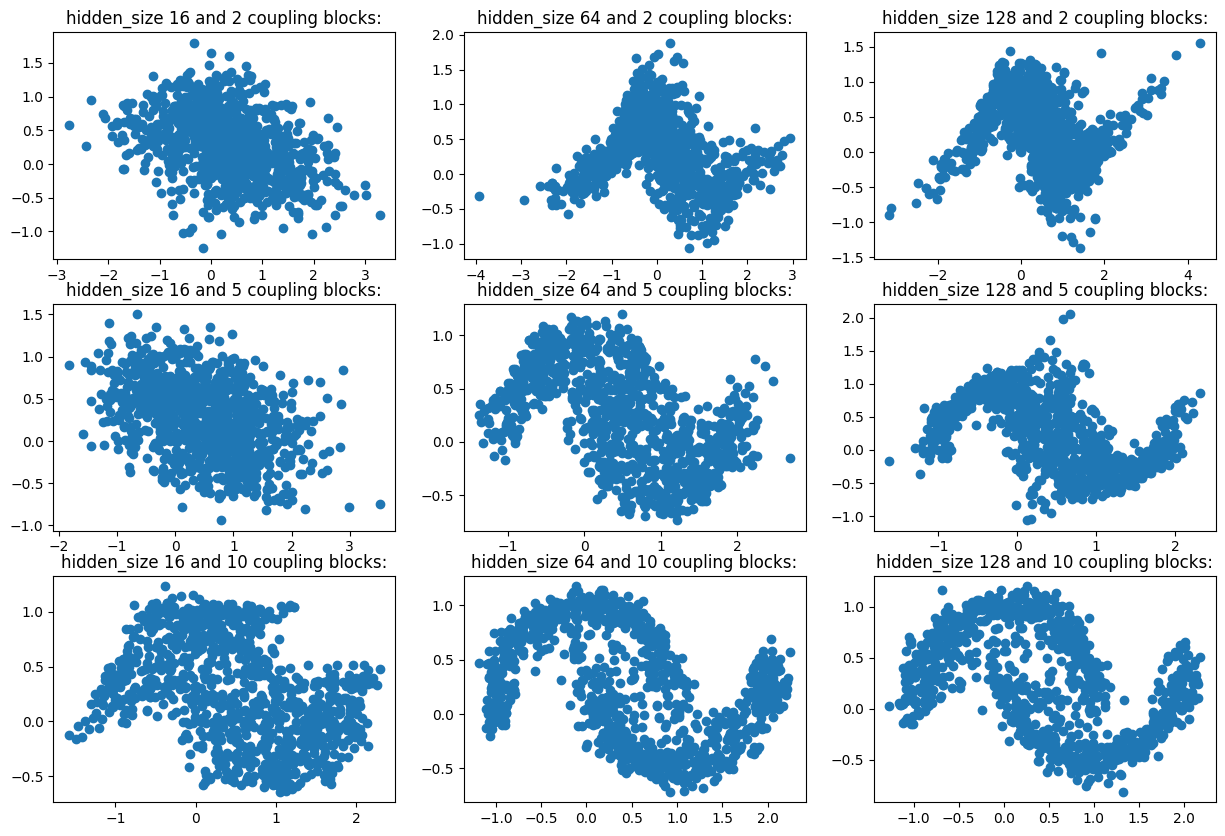

In [89]:
n_blocks = [2, 5, 10]
hidden_sizes = [16, 64, 128]
fig, axs = plt.subplots(3,3,figsize=(15,10))
for n in range(3):
 for h in range(3):
  model = realNVP(2, hidden_sizes[h], n_blocks[n])
  print(f"Training of INN with hidden_size {hidden_sizes[h]} and {n_blocks[n]} coupling blocks started.")
  trainn_inn(model, epochs=100, lr=0.001)
  plot_samples(model, title=f"hidden_size {hidden_sizes[h]} and {n_blocks[n]} coupling blocks:", axs=axs[n, h])


Training of INN with hidden_size 16 and 2 coupling blocks started.
Epoch [333/1000], Loss: -0.1744
Epoch [666/1000], Loss: -0.3026
Epoch [999/1000], Loss: -0.3718
Training of INN with hidden_size 64 and 2 coupling blocks started.
Epoch [333/1000], Loss: -0.3371
Epoch [666/1000], Loss: -0.3600
Epoch [999/1000], Loss: -0.3682
Training of INN with hidden_size 128 and 2 coupling blocks started.
Epoch [333/1000], Loss: -0.2524
Epoch [666/1000], Loss: -0.3410
Epoch [999/1000], Loss: -0.3809
Training of INN with hidden_size 16 and 5 coupling blocks started.
Epoch [333/1000], Loss: -0.5133
Epoch [666/1000], Loss: -0.6270
Epoch [999/1000], Loss: -0.7165
Training of INN with hidden_size 64 and 5 coupling blocks started.
Epoch [333/1000], Loss: -0.8587
Epoch [666/1000], Loss: -0.8960
Epoch [999/1000], Loss: -0.9198
Training of INN with hidden_size 128 and 5 coupling blocks started.
Epoch [333/1000], Loss: -0.6424
Epoch [666/1000], Loss: -0.7870
Epoch [999/1000], Loss: -0.8297
Training of INN with

Training of INN with hidden_size 16 and 2 coupling blocks started.
Epoch [333/1000], Loss: -0.1744
Epoch [666/1000], Loss: -0.3026
Epoch [999/1000], Loss: -0.3718
Training of INN with hidden_size 64 and 2 coupling blocks started.
Epoch [333/1000], Loss: -0.3371
Epoch [666/1000], Loss: -0.3600
Epoch [999/1000], Loss: -0.3682
Training of INN with hidden_size 128 and 2 coupling blocks started.
Epoch [333/1000], Loss: -0.2524
Epoch [666/1000], Loss: -0.3410
Epoch [999/1000], Loss: -0.3809
Training of INN with hidden_size 16 and 5 coupling blocks started.
Epoch [333/1000], Loss: -0.5133
Epoch [666/1000], Loss: -0.6270
Epoch [999/1000], Loss: -0.7165
Training of INN with hidden_size 64 and 5 coupling blocks started.
Epoch [333/1000], Loss: -0.8587
Epoch [666/1000], Loss: -0.8960
Epoch [999/1000], Loss: -0.9198
Training of INN with hidden_size 128 and 5 coupling blocks started.
Epoch [333/1000], Loss: -0.6424
Epoch [666/1000], Loss: -0.7870
Epoch [999/1000], Loss: -0.8297
Training of INN with

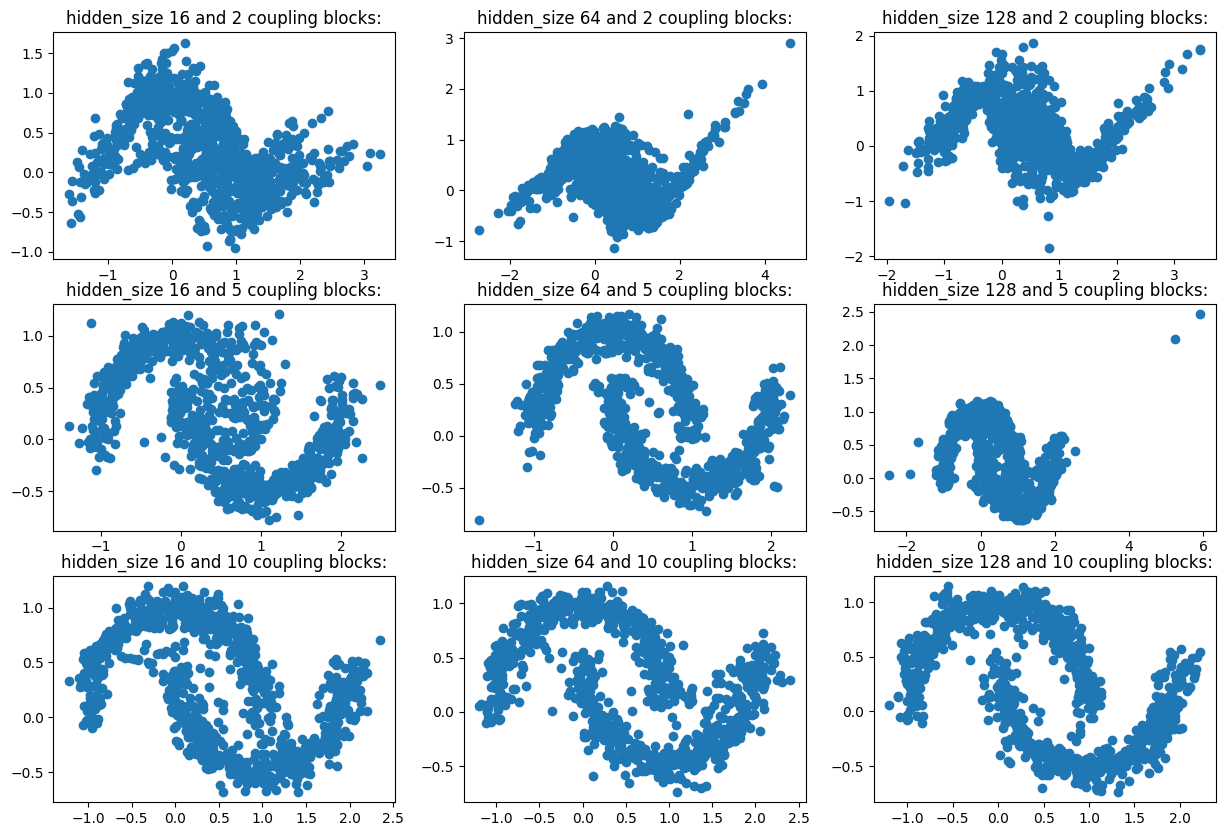

In [90]:
n_blocks = [2, 5, 10]
hidden_sizes = [16, 64, 128]
fig, axs = plt.subplots(3,3,figsize=(15,10))
for n in range(3):
 for h in range(3):
  model = realNVP(2, hidden_sizes[h], n_blocks[n])
  print(f"Training of INN with hidden_size {hidden_sizes[h]} and {n_blocks[n]} coupling blocks started.")
  train_inn(model, epochs=1000, lr=0.001)
  plot_samples(model, title=f"hidden_size {hidden_sizes[h]} and {n_blocks[n]} coupling blocks:", axs=axs[n, h])

Training of INN with hidden_size 64 and 2 coupling blocks started with lr=0.05.
Epoch [333/1000], Loss: -0.5082
Epoch [666/1000], Loss: -0.5459
Epoch [999/1000], Loss: -0.5389
Training of INN with hidden_size 64 and 2 coupling blocks started with lr=0.01.
Epoch [333/1000], Loss: -0.5526
Epoch [666/1000], Loss: -0.5620
Epoch [999/1000], Loss: -0.5732
Training of INN with hidden_size 64 and 2 coupling blocks started with lr=0.0005.
Epoch [333/1000], Loss: -0.3125
Epoch [666/1000], Loss: -0.5263
Epoch [999/1000], Loss: -0.5692
Training of INN with hidden_size 16 and 10 coupling blocks started with lr=0.05.
Epoch [333/1000], Loss: -0.7208
Epoch [666/1000], Loss: -0.7233
Epoch [999/1000], Loss: -0.8275
Training of INN with hidden_size 16 and 10 coupling blocks started with lr=0.01.
Epoch [333/1000], Loss: -0.8433
Epoch [666/1000], Loss: -0.8945
Epoch [999/1000], Loss: -0.9177
Training of INN with hidden_size 16 and 10 coupling blocks started with lr=0.0005.
Epoch [333/1000], Loss: -0.6385
E

Training of INN with hidden_size 64 and 2 coupling blocks started with lr=0.05.
Epoch [333/1000], Loss: -0.5082
Epoch [666/1000], Loss: -0.5459
Epoch [999/1000], Loss: -0.5389
Training of INN with hidden_size 64 and 2 coupling blocks started with lr=0.01.
Epoch [333/1000], Loss: -0.5526
Epoch [666/1000], Loss: -0.5620
Epoch [999/1000], Loss: -0.5732
Training of INN with hidden_size 64 and 2 coupling blocks started with lr=0.0005.
Epoch [333/1000], Loss: -0.3125
Epoch [666/1000], Loss: -0.5263
Epoch [999/1000], Loss: -0.5692
Training of INN with hidden_size 16 and 10 coupling blocks started with lr=0.05.
Epoch [333/1000], Loss: -0.7208
Epoch [666/1000], Loss: -0.7233
Epoch [999/1000], Loss: -0.8275
Training of INN with hidden_size 16 and 10 coupling blocks started with lr=0.01.
Epoch [333/1000], Loss: -0.8433
Epoch [666/1000], Loss: -0.8945
Epoch [999/1000], Loss: -0.9177
Training of INN with hidden_size 16 and 10 coupling blocks started with lr=0.0005.
Epoch [333/1000], Loss: -0.6385
E

'learning_rates = [0.05, 0.01, 0.0005]\nhidden_sizes = [64, 16, 64]\nn_blocks = [2, 10, 10]\nfig, axs = plt.subplots(3,3,figsize=(15,10))\nfor m in range(3):\n for lr in range(3):\n model = realNVP(2, hidden_sizes[m], n_blocks[m])\n print(f"Training of INN with hidden_size {hidden_sizes[m]} and {n_blocks[m]} coupling blocks st\narted with lr={learning_rates[lr]}.")\n train_inn(model, epochs=1000, lr=learning_rates[lr])\n plot_samples(model, title=f"hidden_size {hidden_sizes[m]} and {n_blocks[m]} coupling blocks (lr\n={learning_rates[lr]}):", axs=axs[m, lr])\n'

Training of INN with hidden_size 64 and 2 coupling blocks started with lr=0.05.
Epoch [333/1000], Loss: -0.5082
Epoch [666/1000], Loss: -0.5459
Epoch [999/1000], Loss: -0.5389
Training of INN with hidden_size 64 and 2 coupling blocks started with lr=0.01.
Epoch [333/1000], Loss: -0.5526
Epoch [666/1000], Loss: -0.5620
Epoch [999/1000], Loss: -0.5732
Training of INN with hidden_size 64 and 2 coupling blocks started with lr=0.0005.
Epoch [333/1000], Loss: -0.3125
Epoch [666/1000], Loss: -0.5263
Epoch [999/1000], Loss: -0.5692
Training of INN with hidden_size 16 and 10 coupling blocks started with lr=0.05.
Epoch [333/1000], Loss: -0.7208
Epoch [666/1000], Loss: -0.7233
Epoch [999/1000], Loss: -0.8275
Training of INN with hidden_size 16 and 10 coupling blocks started with lr=0.01.
Epoch [333/1000], Loss: -0.8433
Epoch [666/1000], Loss: -0.8945
Epoch [999/1000], Loss: -0.9177
Training of INN with hidden_size 16 and 10 coupling blocks started with lr=0.0005.
Epoch [333/1000], Loss: -0.6385
E

'learning_rates = [0.05, 0.01, 0.0005]\nhidden_sizes = [64, 16, 64]\nn_blocks = [2, 10, 10]\nfig, axs = plt.subplots(3,3,figsize=(15,10))\nfor m in range(3):\n for lr in range(3):\n model = realNVP(2, hidden_sizes[m], n_blocks[m])\n print(f"Training of INN with hidden_size {hidden_sizes[m]} and {n_blocks[m]} coupling blocks st\narted with lr={learning_rates[lr]}.")\n train_inn(model, epochs=1000, lr=learning_rates[lr])\n plot_samples(model, title=f"hidden_size {hidden_sizes[m]} and {n_blocks[m]} coupling blocks (lr\n={learning_rates[lr]}):", axs=axs[m, lr])\n'

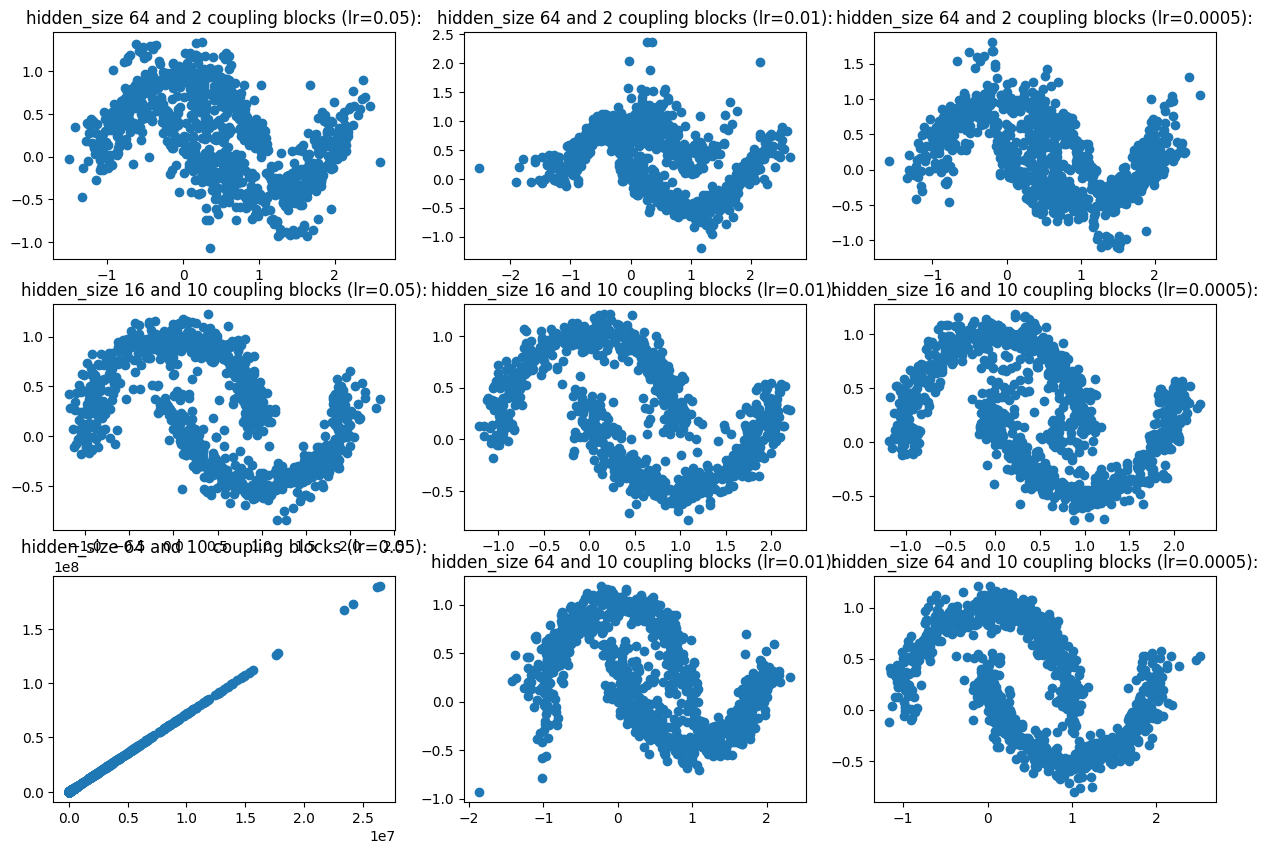

In [91]:
learning_rates = [0.05, 0.01, 0.0005]
hidden_sizes = [64, 16, 64] 
n_blocks = [2, 10, 10]
fig, axs = plt.subplots(3,3,figsize=(15,10))   
for m in range(3):
 for lr in range(3):
  model = realNVP(2, hidden_sizes[m], n_blocks[m])
  print(f"Training of INN with hidden_size {hidden_sizes[m]} and {n_blocks[m]} coupling blocks started with lr={learning_rates[lr]}.")
  train_inn(model, epochs=1000, lr=learning_rates[lr])
  plot_samples(model, title=f"hidden_size {hidden_sizes[m]} and {n_blocks[m]} coupling blocks (lr={learning_rates[lr]}):", axs=axs[m, lr])  
  

"""learning_rates = [0.05, 0.01, 0.0005]
hidden_sizes = [64, 16, 64]
n_blocks = [2, 10, 10]
fig, axs = plt.subplots(3,3,figsize=(15,10))
for m in range(3):
 for lr in range(3):
 model = realNVP(2, hidden_sizes[m], n_blocks[m])
 print(f"Training of INN with hidden_size {hidden_sizes[m]} and {n_blocks[m]} coupling blocks st
arted with lr={learning_rates[lr]}.")
 train_inn(model, epochs=1000, lr=learning_rates[lr])
 plot_samples(model, title=f"hidden_size {hidden_sizes[m]} and {n_blocks[m]} coupling blocks (lr
={learning_rates[lr]}):", axs=axs[m, lr])
"""

In [93]:
def mmd_inverse_multi_quadratic(x, y, bandwidths=None):
 batch_size = x.size()[0]
 # compute the kernel matrices for each combination of x, y
 # (cleverly using broadcasting to do this efficiently)
 xx, yy, xy = torch.mm(x,x.t()), torch.mm(y,y.t()), torch.mm(x,y.t())
 rx = (xx.diag().unsqueeze(0).expand_as(xx))
 ry = (yy.diag().unsqueeze(0).expand_as(yy))
 # compute the sum of kernels at different bandwidths
 K, L, P = 0, 0, 0
 if bandwidths is None:
  bandwidths = [0.4, 0.8, 1.6]
 for sigma in bandwidths:
  s = 1.0 / sigma**2
  K += 1.0 / (1.0 + s * (rx.t() + rx - 2.0*xx))
  L += 1.0 / (1.0 + s * (ry.t() + ry - 2.0*yy))
  P += 1.0 / (1.0 + s * (rx.t() + ry - 2.0*xy))
 beta = 1./(batch_size*(batch_size-1)*len(bandwidths))
 gamma = 2./(batch_size**2 * len(bandwidths))
 return beta * (torch.sum(K)+torch.sum(L)) - gamma * torch.sum(P)



Training of INN with 1 coupling block(s) started.
Epoch [333/1000], Loss: -0.0113
Epoch [666/1000], Loss: -0.0171
Epoch [999/1000], Loss: -0.0191
Training of INN with 2 coupling block(s) started.
Epoch [333/1000], Loss: -0.4791
Epoch [666/1000], Loss: -0.5188
Epoch [999/1000], Loss: -0.5338
Training of INN with 5 coupling block(s) started.
Epoch [333/1000], Loss: -0.6858
Epoch [666/1000], Loss: -0.7701
Epoch [999/1000], Loss: -0.8014
Training of INN with 7 coupling block(s) started.
Epoch [333/1000], Loss: -0.8334
Epoch [666/1000], Loss: -0.9011
Epoch [999/1000], Loss: -0.9448
Training of INN with 10 coupling block(s) started.
Epoch [333/1000], Loss: -0.8477
Epoch [666/1000], Loss: -0.8450
Epoch [999/1000], Loss: -0.9025
Training of INN with 15 coupling block(s) started.
Epoch [333/1000], Loss: -0.9148
Epoch [666/1000], Loss: -0.9749
Epoch [999/1000], Loss: -1.0049


Training of INN with 1 coupling block(s) started.
Epoch [333/1000], Loss: -0.0113
Epoch [666/1000], Loss: -0.0171
Epoch [999/1000], Loss: -0.0191
Training of INN with 2 coupling block(s) started.
Epoch [333/1000], Loss: -0.4791
Epoch [666/1000], Loss: -0.5188
Epoch [999/1000], Loss: -0.5338
Training of INN with 5 coupling block(s) started.
Epoch [333/1000], Loss: -0.6858
Epoch [666/1000], Loss: -0.7701
Epoch [999/1000], Loss: -0.8014
Training of INN with 7 coupling block(s) started.
Epoch [333/1000], Loss: -0.8334
Epoch [666/1000], Loss: -0.9011
Epoch [999/1000], Loss: -0.9448
Training of INN with 10 coupling block(s) started.
Epoch [333/1000], Loss: -0.8477
Epoch [666/1000], Loss: -0.8450
Epoch [999/1000], Loss: -0.9025
Training of INN with 15 coupling block(s) started.
Epoch [333/1000], Loss: -0.9148
Epoch [666/1000], Loss: -0.9749
Epoch [999/1000], Loss: -1.0049


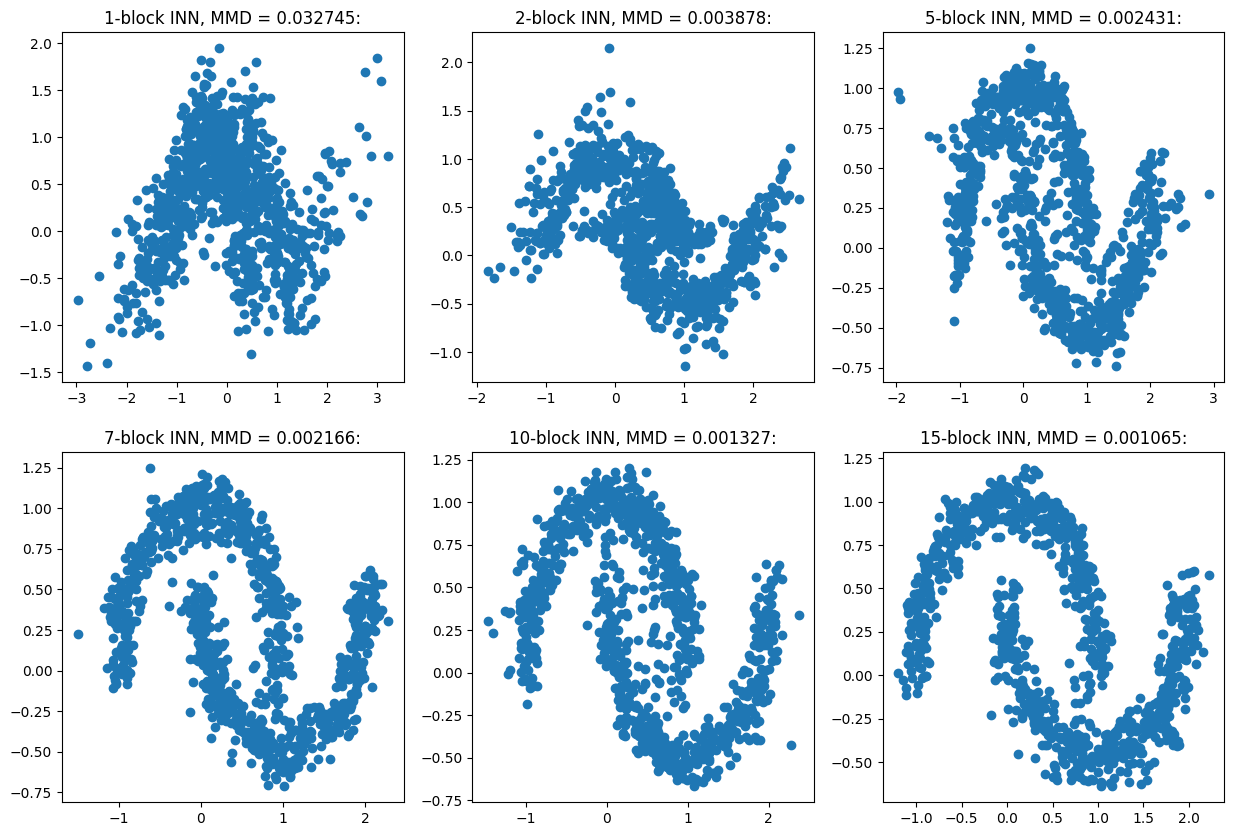

In [94]:
x, _= make_moons(n_samples=1000, shuffle=True, noise=0.1, random_state=42)
x = torch.Tensor(x)
# use n_blocks as variable parameter for model quality
n_blocks = (1, 2, 5, 7, 10, 15)
fig, axs = plt.subplots(2,3,figsize=(15,10))
axs = axs.flatten()
for n in range(6):
 model = realNVP(2, 64, n_blocks[n])
 print(f"Training of INN with {n_blocks[n]} coupling block(s) started.")
 train_inn(model)

 samples = model.sample(1000)
 mmd = mmd_inverse_multi_quadratic(samples, x)

 plot_samples(model, title=f"{n_blocks[n]}-block INN, MMD = {mmd:.6f}:", axs=axs[n])